### [K線捕手](https://www.facebook.com/kevinyang20180801)  

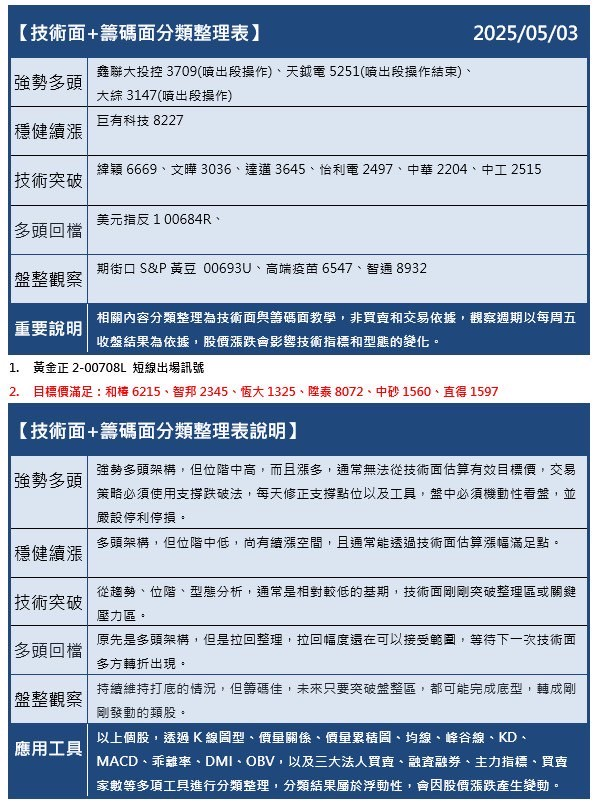  

### 本日進度  
* 量化技術分析系統：規劃與開發  
  - 整合型態識別方法：**不求完美，只求可用**  

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np
import datetime
import myutils

In [2]:
def date_to_index(df_in,date_in) :
    number_array = df_in.index == date_in
    idx = 0
    for number_index in number_array :
        if number_index == True :
            break
        idx = idx + 1
    return idx

In [3]:
def pattern_post_processing( prices , pattern_name, pattern_window) :
    
    # 回傳值
    pattern_return_dict = None
    
    if pattern_name == '雙重頂' or pattern_name == '雙重底' or pattern_name == '三重頂' or pattern_name == '三重底' or pattern_name == '頭肩頂' or pattern_name == '頭肩底' :
        
        pattern_first_date_idx  = pattern_window.iloc[0].name
        pattern_start_date_idx  = pattern_window.iloc[1].name
        pattern_end_date_idx    = pattern_window.iloc[-1].name
        
        neckline_index          = [2,4]
        
        neckline_start_date     = None
        neckline_end_date       = None
        neckline_start_price    = None
        neckline_end_price      = None
        
        pattern_type_char       = ''
        if '頂' in pattern_name :
            pattern_type_char = '頂'
        elif '底' in pattern_name :
            pattern_type_char = '底'
        
        if pattern_name == '雙重頂' or pattern_name == '雙重底':
            neckline_price          = pattern_window.iloc[neckline_index[0]]['Price'] * 1.0
            for idx in range(pattern_first_date_idx,pattern_start_date_idx) :
                if pattern_type_char == '頂' :
                    if prices.iloc[idx]['Close'] > neckline_price or prices.iloc[idx]['Open'] > neckline_price :
                        neckline_start_date  = prices.iloc[idx].name
                        neckline_start_price = neckline_price
                        break
                    else :
                        pass
                elif pattern_type_char == '底' :
                    if prices.iloc[idx]['Close'] < neckline_price or prices.iloc[idx]['Open'] < neckline_price :
                        neckline_start_date  = prices.iloc[idx].name
                        neckline_start_price = neckline_price
                        break
                    else :
                        pass
            for idx in range(pattern_end_date_idx,date_to_index(prices,prices.iloc[-1].name)) :
                if pattern_type_char == '頂' :
                    if prices.iloc[idx]['Close'] < neckline_price or prices.iloc[idx]['Open'] < neckline_price :
                        neckline_end_date  = prices.iloc[idx].name
                        neckline_end_price = neckline_price
                        break
                    else :
                        pass
                elif pattern_type_char == '底' :
                    if prices.iloc[idx]['Close'] > neckline_price or prices.iloc[idx]['Open'] > neckline_price :
                        neckline_end_date  = prices.iloc[idx].name
                        neckline_end_price = neckline_price
                        break
                    else :
                        pass
            if neckline_end_date is None or neckline_end_price is None :
                # 型態進行中
                neckline_end_date  = prices.iloc[-1].name
                neckline_end_price = neckline_price
            else :
                # 型態已跌破／突破
                pass
        elif pattern_name == '三重頂' or pattern_name == '三重底' or pattern_name == '頭肩頂' or pattern_name == '頭肩底' :        
            neckline_x = [date_to_index(prices,pattern_window.iloc[neckline_index[0]]['Date']),date_to_index(prices,pattern_window.iloc[neckline_index[1]]['Date'])]
            neckline_y = [pattern_window.iloc[neckline_index[0]]['Price'],pattern_window.iloc[neckline_index[1]]['Price']]
            neckline_slope,neckline_intercept = np.polyfit(neckline_x,neckline_y,1)
                    
            for idx in range(pattern_first_date_idx,pattern_start_date_idx) :
                on_nickline_price = neckline_slope * idx + neckline_intercept
                if pattern_type_char == '頂' :
                    if prices.iloc[idx]['Close'] > on_nickline_price or prices.iloc[idx]['Open'] > on_nickline_price :
                        neckline_start_date  = prices.iloc[idx].name
                        neckline_start_price = on_nickline_price
                        break
                    else :
                        pass
                elif pattern_type_char == '底' :
                    if prices.iloc[idx]['Close'] < on_nickline_price or prices.iloc[idx]['Open'] < on_nickline_price :
                        neckline_start_date  = prices.iloc[idx].name
                        neckline_start_price = on_nickline_price
                        break
                    else :
                        pass
            for idx in range(pattern_end_date_idx,date_to_index(prices,prices.iloc[-1].name)) :
                on_nickline_price = neckline_slope * idx + neckline_intercept
                if pattern_type_char == '頂' :
                    if prices.iloc[idx]['Close'] < on_nickline_price or prices.iloc[idx]['Open'] < on_nickline_price :
                        neckline_end_date  = prices.iloc[idx].name
                        neckline_end_price = on_nickline_price
                        break
                    else :
                        pass
                elif pattern_type_char == '底' :
                    if prices.iloc[idx]['Close'] > on_nickline_price or prices.iloc[idx]['Open'] > on_nickline_price :
                        neckline_end_date  = prices.iloc[idx].name
                        neckline_end_price = on_nickline_price
                        break
                    else :
                        pass
            if neckline_end_date is None or neckline_end_price is None :
                # 型態進行中
                neckline_end_date  = prices.iloc[-1].name
                neckline_end_price = neckline_slope * date_to_index(prices,prices.iloc[-1].name) + neckline_intercept
            else :
                # 型態已跌破／突破
                pass
            # 確認頸線是否存在
            if neckline_start_date is None or neckline_end_date is None or neckline_start_price is None or neckline_end_price is None :
                print('  ╳ 找不到頸線？')
            else :
                # 建立型態資料
                pattern_data_dict   = {'neckline_start_date':neckline_start_date,'neckline_end_date':neckline_end_date,'neckline_start_price':neckline_start_price,'neckline_end_price':neckline_end_price,'window':pattern_window}
                pattern_return_dict = {'類型' : '反轉型態', '型態' : pattern_name, '資料' : pattern_data_dict}
    elif pattern_name == '三角形' : 
        
        pattern_end_date_idx        = pattern_window.iloc[-1].name
        
        resistance_line_index       = [0,4]
        support_line_idx            = [1,3]
        
        resistance_line_start_date  = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
        resistance_line_end_date    = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
        resistance_line_x           = [date_to_index(prices,pattern_window.iloc[resistance_line_index[0]]['Date']),date_to_index(prices,pattern_window.iloc[resistance_line_index[1]]['Date'])]
        resistance_line_y           = [pattern_window.iloc[resistance_line_index[0]]['Price'],pattern_window.iloc[resistance_line_index[1]]['Price']]
        resistance_line_slope,resistance_line_intercept = np.polyfit(resistance_line_x,resistance_line_y,1)
        resistance_line_start_price = resistance_line_slope * date_to_index(prices,resistance_line_start_date) + resistance_line_intercept
        resistance_line_end_price   = resistance_line_slope * date_to_index(prices,resistance_line_end_date) + resistance_line_intercept
                
        support_line_start_date     = resistance_line_start_date
        support_line_end_date       = resistance_line_end_date
        support_line_x              = [date_to_index(prices,pattern_window.iloc[support_line_idx[0]]['Date']),date_to_index(prices,pattern_window.iloc[support_line_idx[1]]['Date'])]
        support_line_y              = [pattern_window.iloc[support_line_idx[0]]['Price'],pattern_window.iloc[support_line_idx[1]]['Price']]
        support_line_slope,support_line_intercept = np.polyfit(support_line_x,support_line_y,1)
        support_line_start_price    = support_line_slope * date_to_index(prices,support_line_start_date) + support_line_intercept
        support_line_end_price      = support_line_slope * date_to_index(prices,support_line_end_date) + support_line_intercept
        
        if support_line_end_price > resistance_line_end_price :
            print("  ╳ 無效的三角形型態！")
        else :
            # 趨勢線向後延伸
            for idx in range(pattern_end_date_idx+1,date_to_index(prices,prices.iloc[-1].name)) :
                tmp_resistance_price = resistance_line_slope * idx + resistance_line_intercept
                tmp_support_price    = support_line_slope * idx + support_line_intercept
                if prices.iloc[idx]['Close'] > tmp_resistance_price or prices.iloc[idx]['Open'] > tmp_resistance_price or \
                  prices.iloc[idx]['Close'] < tmp_support_price or prices.iloc[idx]['Open'] < tmp_support_price :
                    break
                else :
                    resistance_line_end_date  = prices.iloc[idx].name
                    resistance_line_end_price = tmp_resistance_price
                    support_line_end_date     = resistance_line_end_date
                    support_line_end_price    = tmp_support_price
            # 建立型態資料
            pattern_data_dict = {'resistance_line_start_date' : resistance_line_start_date , 'resistance_line_end_date' : resistance_line_end_date , \
                                 'resistance_line_start_price' : resistance_line_start_price, 'resistance_line_end_price' : resistance_line_end_price, \
                                 'support_line_start_date' : support_line_start_date, 'support_line_end_date' : support_line_end_date, \
                                 'support_line_start_price' : support_line_start_price , 'support_line_end_price' : support_line_end_price, \
                                 'window':pattern_window}
            pattern_return_dict = {'類型' : '盤整型態', '型態' : pattern_name, '資料' : pattern_data_dict}
    elif pattern_name == '上升楔型' or pattern_name == '下降楔型' :
        
        pattern_end_date_idx        = pattern_window.iloc[-1].name
        
        if pattern_name == '上升楔型' :
            resistance_line_index   = [1,3]
            support_line_idx        = [0,2]
        else :
            resistance_line_index   = [0,2]
            support_line_idx        = [1,3]
        
        resistance_line_start_date  = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
        resistance_line_end_date    = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
        resistance_line_x           = [date_to_index(prices,pattern_window.iloc[resistance_line_index[0]]['Date']),date_to_index(prices,pattern_window.iloc[resistance_line_index[1]]['Date'])]
        resistance_line_y           = [pattern_window.iloc[resistance_line_index[0]]['Price'],pattern_window.iloc[resistance_line_index[1]]['Price']]
        resistance_line_slope,resistance_line_intercept = np.polyfit(resistance_line_x,resistance_line_y,1)
        resistance_line_start_price = resistance_line_slope * date_to_index(prices,resistance_line_start_date) + resistance_line_intercept
        resistance_line_end_price   = resistance_line_slope * date_to_index(prices,resistance_line_end_date) + resistance_line_intercept
                
        support_line_start_date     = resistance_line_start_date
        support_line_end_date       = resistance_line_end_date
        support_line_x              = [date_to_index(prices,pattern_window.iloc[support_line_idx[0]]['Date']),date_to_index(prices,pattern_window.iloc[support_line_idx[1]]['Date'])]
        support_line_y              = [pattern_window.iloc[support_line_idx[0]]['Price'],pattern_window.iloc[support_line_idx[1]]['Price']]
        support_line_slope,support_line_intercept = np.polyfit(support_line_x,support_line_y,1)
        support_line_start_price    = support_line_slope * date_to_index(prices,support_line_start_date) + support_line_intercept
        support_line_end_price      = support_line_slope * date_to_index(prices,support_line_end_date) + support_line_intercept
        
        # 趨勢線向後延伸
        for idx in range(pattern_end_date_idx+1,date_to_index(prices,prices.iloc[-1].name)) :
            tmp_resistance_price = resistance_line_slope * idx + resistance_line_intercept
            tmp_support_price    = support_line_slope * idx + support_line_intercept
            if prices.iloc[idx]['Close'] > tmp_resistance_price or prices.iloc[idx]['Open'] > tmp_resistance_price or \
              prices.iloc[idx]['Close'] < tmp_support_price or prices.iloc[idx]['Open'] < tmp_support_price :
                break
            else :
                resistance_line_end_date  = prices.iloc[idx].name
                resistance_line_end_price = tmp_resistance_price
                support_line_end_date     = resistance_line_end_date
                support_line_end_price    = tmp_support_price
        # 建立型態資料
        pattern_data_dict = {'resistance_line_start_date' : resistance_line_start_date , 'resistance_line_end_date' : resistance_line_end_date , \
                             'resistance_line_start_price' : resistance_line_start_price, 'resistance_line_end_price' : resistance_line_end_price, \
                             'support_line_start_date' : support_line_start_date, 'support_line_end_date' : support_line_end_date, \
                             'support_line_start_price' : support_line_start_price , 'support_line_end_price' : support_line_end_price, \
                             'window':pattern_window}
        pattern_return_dict = {'類型' : '反轉型態', '型態' : pattern_name, '資料' : pattern_data_dict}
    elif pattern_name == '矩形' :
        
        pattern_end_date_idx        = pattern_window.iloc[-1].name
        
        rect_upper_edge_price =  max(pattern_window.iloc[0]['Price'],pattern_window.iloc[2]['Price'])
        rect_lower_edge_price =  min(pattern_window.iloc[1]['Price'],pattern_window.iloc[3]['Price'])

        resistance_line_start_date = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
        resistance_line_end_date   = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
        resistance_line_price      = rect_upper_edge_price
        
        support_line_start_date    = resistance_line_start_date
        support_line_end_date      = resistance_line_end_date
        support_line_price         = rect_lower_edge_price
        
        print(resistance_line_end_date,support_line_end_date)
        
        # 趨勢線向後延伸
        for idx in range(pattern_end_date_idx+1,date_to_index(prices,prices.iloc[-1].name)) :
            if prices.iloc[idx]['Close'] > resistance_line_price or prices.iloc[idx]['Open'] > resistance_line_price or \
              prices.iloc[idx]['Close'] < support_line_price or prices.iloc[idx]['Open'] < support_line_price :
                break
            else :
                resistance_line_end_date  = prices.iloc[idx].name
                support_line_end_date     = resistance_line_end_date
        # 建立型態資料
        pattern_data_dict = {'resistance_line_start_date' : resistance_line_start_date , 'resistance_line_end_date' : resistance_line_end_date , \
                             'resistance_line_price' : resistance_line_price, \
                             'support_line_start_date' : support_line_start_date, 'support_line_end_date' : support_line_end_date, \
                             'support_line_price' : support_line_price, \
                             'window':pattern_window}
        pattern_return_dict = {'類型' : '盤整型態', '型態' : pattern_name, '資料' : pattern_data_dict}
    elif pattern_name == '上升旗形' or pattern_name == '下降旗形' or pattern_name == '看跌三角旗形' or pattern_name == '看漲三角旗形'  : 
        
        if pattern_name == '上升旗形' or pattern_name == '看跌三角旗形':
            resistance_line_index   = [2,4]
            support_line_idx        = [1,3]
        else :
            resistance_line_index   = [1,3]
            support_line_idx        = [2,4]
        
        resistance_line_start_date  = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
        resistance_line_end_date    = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
        resistance_line_x           = [date_to_index(prices,pattern_window.iloc[resistance_line_index[0]]['Date']),date_to_index(prices,pattern_window.iloc[resistance_line_index[1]]['Date'])]
        resistance_line_y           = [pattern_window.iloc[resistance_line_index[0]]['Price'],pattern_window.iloc[resistance_line_index[1]]['Price']]
        resistance_line_slope,resistance_line_intercept = np.polyfit(resistance_line_x,resistance_line_y,1)
        resistance_line_start_price = resistance_line_slope * date_to_index(prices,resistance_line_start_date) + resistance_line_intercept
        resistance_line_end_price   = resistance_line_slope * date_to_index(prices,resistance_line_end_date) + resistance_line_intercept
                
        support_line_start_date     = resistance_line_start_date
        support_line_end_date       = resistance_line_end_date
        support_line_x              = [date_to_index(prices,pattern_window.iloc[support_line_idx[0]]['Date']),date_to_index(prices,pattern_window.iloc[support_line_idx[1]]['Date'])]
        support_line_y              = [pattern_window.iloc[support_line_idx[0]]['Price'],pattern_window.iloc[support_line_idx[1]]['Price']]
        support_line_slope,support_line_intercept = np.polyfit(support_line_x,support_line_y,1)
        support_line_start_price    = support_line_slope * date_to_index(prices,support_line_start_date) + support_line_intercept
        support_line_end_price      = support_line_slope * date_to_index(prices,support_line_end_date) + support_line_intercept
        
        # 趨勢線向後延伸
        for idx in range(pattern_end_date_idx+1,date_to_index(prices,prices.iloc[-1].name)) :
            tmp_resistance_price = resistance_line_slope * idx + resistance_line_intercept
            tmp_support_price    = support_line_slope * idx + support_line_intercept
            if prices.iloc[idx]['Close'] > tmp_resistance_price or prices.iloc[idx]['Open'] > tmp_resistance_price or \
              prices.iloc[idx]['Close'] < tmp_support_price or prices.iloc[idx]['Open'] < tmp_support_price :
                break
            else :
                resistance_line_end_date  = prices.iloc[idx].name
                resistance_line_end_price = tmp_resistance_price
                support_line_end_date     = resistance_line_end_date
                support_line_end_price    = tmp_support_price
        # 建立型態資料
        pattern_data_dict = {'resistance_line_start_date' : resistance_line_start_date , 'resistance_line_end_date' : resistance_line_end_date , \
                             'resistance_line_start_price' : resistance_line_start_price, 'resistance_line_end_price' : resistance_line_end_price, \
                             'support_line_start_date' : support_line_start_date, 'support_line_end_date' : support_line_end_date, \
                             'support_line_start_price' : support_line_start_price , 'support_line_end_price' : support_line_end_price, \
                             'window':pattern_window}
        pattern_return_dict = {'類型' : '中繼型態', '型態' : pattern_name, '資料' : pattern_data_dict}
        
    else :
        pass
        
    return pattern_return_dict

In [4]:
def chart_pattern_recognition( prices):
    # 型態回傳字典
    pattern_return_list = []
    
    # 建立「股票技術型態識別」物件
    chart_pattern = myutils.StockChartPatterns(prices,debug=True)
    
    # 識別：底型反轉操作法之底部型態
    bottom_pattern_exist = False
    turning_point_args   = []
    turning_point_args.append({'mode':'close', 'order':10, 'smoothing':3})
    turning_point_args.append({'mode':'open_close', 'order':5})
    patterns = chart_pattern.RecognitionBottom(turning_point_args=turning_point_args)
    if patterns is not None and len(patterns) > 0 :
        print('☆ 底型反轉操作法之底部型態 ＝ {}'.format(patterns))
        # 只保留最後一個底部型態
        bottom_pattern = patterns[-1]['bottom_pattern']
        if date_to_index(prices,bottom_pattern['neckline_end_date']) > (date_to_index(prices,prices.iloc[-1].name) / 2) :
            pattern_return_list.append({'類型' : '底型反轉', '型態' : '底部型態', '資料' : bottom_pattern })
            bottom_pattern_exist = True
        else :
            print('◆ 找到的底部型態太靠前 ： 頸線結束日期 ＝ {} （索引 ＝ {}）， 價格資料的最後一個索引 ＝ {} '.format(bottom_pattern['neckline_end_date'],date_to_index(prices,bottom_pattern['neckline_end_date']),date_to_index(prices,pattern_window.iloc[-1]['Date'])))
 
    #  識別：ＧＰＴ－４ｏ之主要型態
    gpt4o_pattern_exist           = False
    possible_pattern_name_list    = None
    gpt4o_major_pattern_start_idx = -1
    gpt4o_major_pattern_end_idx   = -1
    patterns = chart_pattern.RecognitionUsingGPT4o()
    if patterns is not None and type(patterns) is list :
        print('☆ GPT-4o版之主要型態 ＝ {}'.format(patterns))
        pattern            = patterns[0]
        pattern_start_date = pattern['start']
        pattern_end_date   = pattern['end']
        if pattern_start_date not in prices.index or pattern_end_date not in prices.index :
            print('■ 主要型態的開始或結束日期不在價格內，進行日期校正')
            prices_start_date = datetime.datetime.strptime(prices.iloc[0].name, '%Y-%m-%d')
            prices_end_date   = datetime.datetime.strptime(prices.iloc[-1].name, '%Y-%m-%d')
            next_start_date   = pattern_start_date
            while True :
                start_date = datetime.datetime.strptime(next_start_date, '%Y-%m-%d')
                if start_date == prices_start_date :
                    print('□ 日期校正：到頭')
                    break
                next_start_date = (start_date + datetime.timedelta(days=1)).strftime('%Y-%m-%d')
                if next_start_date in prices.index :
                    pattern_start_date = next_start_date
                    print('□ 日期校正結果 ： 開始日期 ＝ {}'.format(pattern_start_date))
                    break
            prev_end_date = pattern_end_date
            while True :
                end_date = datetime.datetime.strptime(prev_end_date, '%Y-%m-%d')
                if end_date == prices_end_date :
                    print('□ 日期校正：到底')
                    break
                prev_end_date = (end_date - datetime.timedelta(days=1)).strftime('%Y-%m-%d')
                if prev_end_date in prices.index :
                    pattern_end_date = prev_end_date
                    print('□ 日期校正結果 ： 結束日期 ＝ {}'.format(pattern_end_date))
                    break
        if pattern_start_date in prices.index and pattern_end_date in prices.index :
            gpt4o_major_pattern_start_idx = date_to_index(prices,pattern_start_date)
            gpt4o_major_pattern_end_idx   = date_to_index(prices,pattern_end_date)
            if gpt4o_major_pattern_end_idx > (date_to_index(prices,prices.iloc[-1].name) / 2) :
                # 列出可能的型態名稱
                pattern_type               = pattern['type']
                possible_pattern_name_list = []
                if '頂' in pattern_type :
                    possible_pattern_name_list.append('頭肩頂')
                    possible_pattern_name_list.append('三重頂')
                    possible_pattern_name_list.append('雙重頂')
                elif '底' in pattern_type and bottom_pattern_exist is False :
                    possible_pattern_name_list.append('頭肩底')
                    possible_pattern_name_list.append('三重底')
                    possible_pattern_name_list.append('雙重底')
                elif '旗形' in pattern_type :
                    possible_pattern_name_list.append('上升旗形')
                    possible_pattern_name_list.append('下降旗形')
                    possible_pattern_name_list.append('看跌三角旗形')
                    possible_pattern_name_list.append('看漲三角旗形')
                elif '三角形' in pattern_type :
                    possible_pattern_name_list.append('三角形')
                    possible_pattern_name_list.append('上升楔型')
                    possible_pattern_name_list.append('下降楔型')
                elif '矩形' in pattern_type :
                    possible_pattern_name_list.append('矩形')
                else :
                    pass
                print('→ 可能的型態名稱 ＝ {}'.format(possible_pattern_name_list))
            else :
                print('◆ 找到的主要型態太靠前 ： 型態結束日期索引 ＝ {} （索引 ＝ {}） ， 價格資料的最後一個索引 ＝ {} '.format(pattern['end'],gpt4o_major_pattern_end_idx,date_to_index(prices,pattern_window.iloc[-1]['Date'])))
        if possible_pattern_name_list is not None and len(possible_pattern_name_list) > 0 :
            # 由轉折點識別型態
            turning_point_args = []
            turning_point_args.append({'mode':'close', 'order':10, 'smoothing':3})
            turning_point_args.append({'mode':'open_close', 'order':5})
            turning_point_args.append({'mode':'open_close', 'order':10})
            turning_point_args.append({'mode':'open_close', 'order':15})
            turning_point_args.append({'mode':'open_close', 'order':20})
            turning_point_args.append({'mode':'open_close', 'order':25})
            turning_point_args.append({'mode':'open_close', 'order':30})
            patterns = chart_pattern.Recognition(max_bars=360, turning_point_args=turning_point_args)
            if patterns is not None and len(patterns) > 0 :
                # 變數：與GPT-4o主要型態相符之距離
                major_pattern_distance = sys.maxsize
                # 變數：候選型態
                candidate_pattern      = None
                # 過濾找到的型態，對照GPT-4o版之主要型態
                for pattern_name in patterns:
                    if pattern_name in possible_pattern_name_list :
                        for pattern in patterns[pattern_name] :
                            window            = pattern['window']
                            pattern_start_idx = window.iloc[1].name
                            pattern_end_idx   = window.iloc[-1].name
                            pattern_distance  = abs(gpt4o_major_pattern_start_idx - pattern_start_idx) + abs(gpt4o_major_pattern_end_idx - pattern_end_idx)
                            if pattern_distance < major_pattern_distance :
                                print('pattern_name = {} , gpt4o_major_pattern_start_idx = {} , gpt4o_major_pattern_end_idx = {} , pattern_start_idx = {} , pattern_end_idx = {} '.format(pattern_name,gpt4o_major_pattern_start_idx,gpt4o_major_pattern_end_idx,pattern_start_idx,pattern_end_idx))
                                major_pattern_distance = pattern_distance
                                candidate_pattern         = [pattern_name,pattern['argument'],pattern['window']]
                # 如果有候選型態
                if candidate_pattern is not None :
                    pattern_name   = candidate_pattern[0]
                    pattern_window = candidate_pattern[2]
                    result = pattern_post_processing( prices, pattern_name, pattern_window)
                    if result is not None :
                        pattern_return_list.append(result)
                        gpt4o_pattern_exist = True
    
    # 由轉折點識別型態
    if gpt4o_pattern_exist is False :
        turning_point_args = []
        turning_point_args.append({'mode':'close', 'order':10, 'smoothing':3})
        turning_point_args.append({'mode':'open_close', 'order':10})
        turning_point_args.append({'mode':'open_close', 'order':20})
        patterns = chart_pattern.Recognition(max_bars=360, turning_point_args=turning_point_args)
        if patterns is not None and len(patterns) > 0 :
            possible_pattern = None
            for pattern_name in patterns:
                if bottom_pattern_exist is True and '底' in pattern_name :
                    continue
                for pattern in patterns[pattern_name] :
                    if possible_pattern is None :
                        possible_pattern = [pattern_name,pattern['argument'],pattern['window']]
                    else :
                        current_pattern_last_idx  = pattern['window'].iloc[-1]
                        possible_pattern_last_idx = possible_pattern[2].iloc[-1]
                        price_last_idx            = date_to_index(prices,prices.iloc[-1].name)
                        
                        if (current_pattern_last_idx - price_last_idx) < (possible_pattern_last_idx - price_last_idx) :
                            possible_pattern = [pattern_name,pattern['argument'],pattern['window']]
            if possible_pattern is not None :
                pattern_name   = possible_pattern[0]
                pattern_window = possible_pattern[2]
                result = pattern_post_processing( prices, pattern_name, pattern_window)
                if result is not None :
                    pattern_return_list.append(result)
 
    return pattern_return_list

In [5]:
def chart_pattern_visualization(prices,recognition_patterns) :
    
    seq_of_seq_of_points = []
    apds                 = [] 
    
    for recognition_pattern in recognition_patterns :
        pattern_type = recognition_pattern['類型']
        pattern_name = recognition_pattern['型態']
        pattern      = recognition_pattern['資料']
        
        if pattern_type == '底型反轉' :
            bottom_pattern          = pattern
            bottom_pattern_breakout = False
            if 'bottom_pattern_breakout_date' in bottom_pattern :
                bottom_pattern_breakout_date  = bottom_pattern['bottom_pattern_breakout_date']
                bottom_pattern_breakout_price = bottom_pattern['bottom_pattern_breakout_price']
                bottom_pattern_breakout = True
            neckline_start_date  = bottom_pattern['neckline_start_date']
            neckline_start_price = bottom_pattern['neckline_start_price']
            neckline_end_date    = bottom_pattern['neckline_end_date']
            neckline_end_price   = bottom_pattern['neckline_end_price']
            
            # 設定頸線
            seq_of_seq_of_points.append([(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)])
        elif pattern_type == '反轉型態' or pattern_type == '盤整型態' or pattern_type == '中繼型態' :
            pattern_window = pattern['window']
            if pattern_name == '雙重頂' or pattern_name == '雙重底' or pattern_name == '三重頂' or pattern_name == '三重底' or pattern_name == '頭肩頂' or pattern_name == '頭肩底' :
                # 設定頸線
                neckline_start_date  = pattern['neckline_start_date']
                neckline_start_price = pattern['neckline_start_price']
                neckline_end_date    = pattern['neckline_end_date']
                neckline_end_price   = pattern['neckline_end_price']
                seq_of_seq_of_points.append([(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)])
            elif pattern_name == '矩形':
                # 設定趨勢線
                resistance_line_start_date  = pattern['resistance_line_start_date']
                resistance_line_end_date    = pattern['resistance_line_end_date']
                resistance_line_price       = pattern['resistance_line_price']
                support_line_start_date     = pattern['support_line_start_date']
                support_line_end_date       = pattern['support_line_end_date']
                support_line_price          = pattern['support_line_price']
                seq_of_seq_of_points.append([(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)])
                seq_of_seq_of_points.append([(support_line_start_date,support_line_price),(support_line_end_date,support_line_price)])
            else :
                # 設定趨勢線
                resistance_line_start_date  = pattern['resistance_line_start_date']
                resistance_line_end_date    = pattern['resistance_line_end_date']
                resistance_line_start_price = pattern['resistance_line_start_price']
                resistance_line_end_price   = pattern['resistance_line_end_price']
                support_line_start_date     = pattern['support_line_start_date']
                support_line_end_date       = pattern['support_line_end_date']
                support_line_start_price    = pattern['support_line_start_price']
                support_line_end_price      = pattern['support_line_end_price']
                seq_of_seq_of_points.append([(resistance_line_start_date,resistance_line_start_price),(resistance_line_end_date,resistance_line_end_price)])
                seq_of_seq_of_points.append([(support_line_start_date,support_line_start_price),(support_line_end_date,support_line_end_price)])
            # 設定轉折點
            turning_points_len = len(np.array(prices['Close']))
            turning_points = np.array([np.nan]*turning_points_len)
            for point in pattern_window.iterrows() :
                turning_points[point[0]] = point[1]['Price']
            apds.append(mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=25,color='xkcd:sky blue'))
        else :
            pass
    
    # 設定K線格式
    mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
    s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
    # 設定參數
    kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True, addplot=apds, alines=dict(alines=seq_of_seq_of_points, linewidths=2, colors='xkcd:orange yellow', alpha=0.6), datetime_format='%Y-%m-%d', warn_too_much_data=2000)
    # 繪製K線圖
    mpf.plot(prices,**kwargs)

> 近期型態  

In [6]:
##### 使用2023年8月25日到2025年5月2日收盤之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_TSE_250502.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

> 矩形？箱型？

ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}]
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 19） 
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 41） 
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 389 （日期 ＝ 2025-04-09 ） ， 底部型態結束索引 ＝ 400 （日期 ＝ 2025-04-24 ）
ＤＥＢＵＧ ： 趨勢線開始索引 ＝ 0（價格資料開始索引 ＝ 389），趨勢線結束索引 ＝ 11（價格資料結束索引 ＝ 400）
ＤＥＢＵＧ ： 頸線角度（絕對值） ＝ 2.08°
ＤＥＢＵＧ ： 底部型態突破確認範圍 ： 400 ～ 406
ＤＥＢＵＧ ： 確認底部型態突破，收盤價超過頸線３％。價格索引 ＝ 405 ， 日期 ＝ 2025-05-02 ， 突破時頸線價格 ＝ 19758.63元 
ＤＥＢＵＧ ： 底部最低價格 ＝ 17391.76元 ； 估算目標價 ＝ 22257.56元
☆ 底型反轉操作法之底部型態 ＝ [{'argument': {'mode': 'open_close', 'order': 5}, 'bottom_pattern': {'neckline_start_date': '2025-04-02', 'neckline_start_price': 19915.44092140465, 'neckline_end_date': '2025-05-02', 'neckline_end_price': 19758.63413473488, 'bottom_pattern_breakout_date': '2025-05-02', 'bottom_pattern_breakout_price': 19758.63413473488, 'bottom_price_date': '2025-04-09', 'bottom_price': 17391.76, 'on_neckline_price': 19890.68195508837, 'target_price': 22257.55608982325}}]
☆ GPT-4o版之主

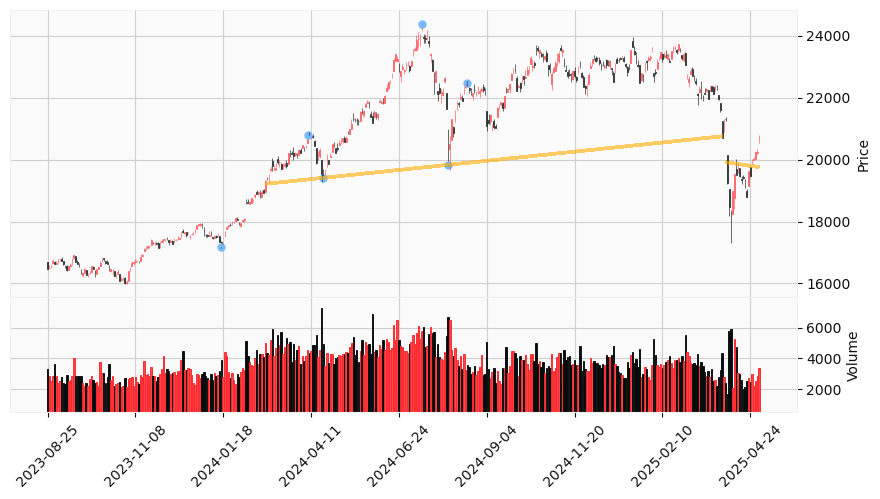

In [7]:
result = chart_pattern_recognition(df_k_line)
chart_pattern_visualization(df_k_line,result)

ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}]
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 9） 
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 18） 
☆ GPT-4o版之主要型態 ＝ [{'type': '矩形整理', 'start': '2024-10-24', 'end': '2025-03-05'}]
→ 可能的型態名稱 ＝ ['矩形']
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}, {'mode': 'open_close', 'order': 10}, {'mode': 'open_close', 'order': 15}, {'mode': 'open_close', 'order': 20}, {'mode': 'open_close', 'order': 25}, {'mode': 'open_close', 'order': 30}]
pattern_name = 矩形 , gpt4o_major_pattern_start_idx = 42 , gpt4o_major_pattern_end_idx = 126 , pattern_start_idx = 47 , pattern_end_idx = 58 
pattern_name = 矩形 , gpt4o_major_pattern_start_idx = 42 , gpt4o_major_pattern_end_idx = 126 , pattern_start_idx = 67 , pattern_end_idx = 82 
pattern_name = 矩形 , gpt4o_major_pattern_start_idx = 42 , gpt4o_major_pattern_end_idx = 126 , pattern_start_idx = 47 , pattern_end_idx = 67 
pattern_n

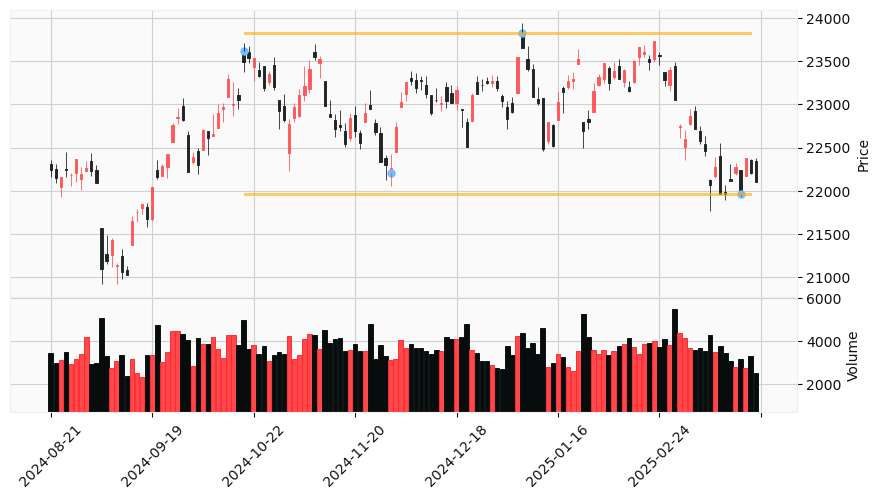

In [8]:
# 區間價格
range_prices = df_k_line['2024-08-21':'2025-03-24']
result = chart_pattern_recognition(range_prices)
chart_pattern_visualization(range_prices,result)

> 上升楔型？  

In [9]:
##### 使用2024年6月17日到2025年2月17日收盤之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_2330_250217.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}]
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 5） 
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 16） 
☆ GPT-4o版之主要型態 ＝ [{'type': '上升三角形', 'start': '2024-09-18', 'end': '2025-01-21'}]
→ 可能的型態名稱 ＝ ['三角形', '上升楔型', '下降楔型']
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}, {'mode': 'open_close', 'order': 10}, {'mode': 'open_close', 'order': 15}, {'mode': 'open_close', 'order': 20}, {'mode': 'open_close', 'order': 25}, {'mode': 'open_close', 'order': 30}]
pattern_name = 上升楔型 , gpt4o_major_pattern_start_idx = 63 , gpt4o_major_pattern_end_idx = 147 , pattern_start_idx = 96 , pattern_end_idx = 147 
pattern_name = 上升楔型 , gpt4o_major_pattern_start_idx = 63 , gpt4o_major_pattern_end_idx = 147 , pattern_start_idx = 82 , pattern_end_idx = 137 


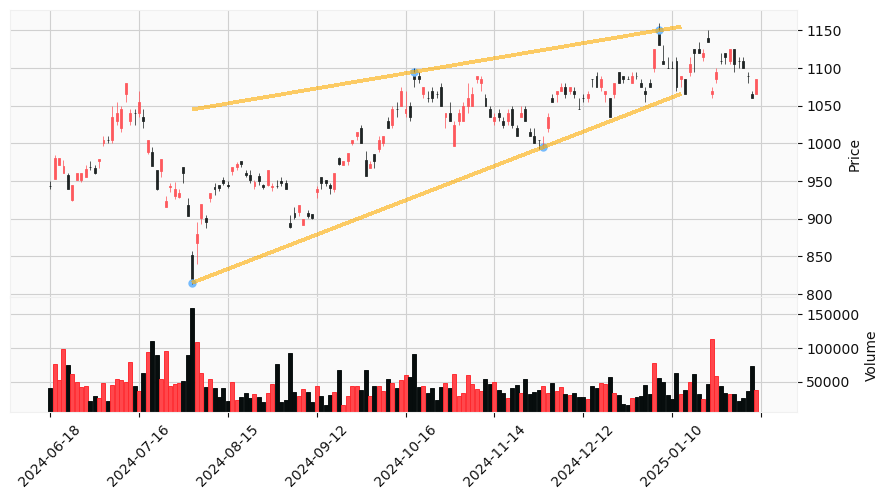

In [10]:
result = chart_pattern_recognition(df_k_line)
chart_pattern_visualization(df_k_line,result)